# NB03: Sparse Annotation Mining — Clue Matrix

**Goal**: Build a "clue matrix" cataloging all partial annotations for each truly dark gene. Cluster by clue profile and validate that more clues correlate with higher cross-organism concordance.

**Input**: NB01 truly_dark_genes.tsv + NB02 enrichment files (pfam, xrefs, eggnog, orthologs) + fitness_modules gene_membership data

**Output**: `data/truly_dark_clue_matrix.tsv`, clue coverage figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import glob

OUT = '../data'
FIG = '../figures'
os.makedirs(FIG, exist_ok=True)
FM_DIR = '../../fitness_modules/data/modules'
FDM_DIR = '../../functional_dark_matter/data'

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load All Data Sources

In [2]:
# Core truly dark genes
td = pd.read_csv(f'{OUT}/truly_dark_genes.tsv', sep='\t')
print(f'Truly dark genes: {len(td):,}')

# NB02 enrichment data
pfam = pd.read_csv(f'{OUT}/truly_dark_pfam.tsv', sep='\t')
xrefs = pd.read_csv(f'{OUT}/truly_dark_xrefs.tsv', sep='\t')
eggnog = pd.read_csv(f'{OUT}/truly_dark_eggnog.tsv', sep='\t')
orthologs = pd.read_csv(f'{OUT}/truly_dark_orthologs.tsv', sep='\t')
gene_props = pd.read_csv(f'{OUT}/gene_properties.tsv', sep='\t')
print(f'Pfam: {len(pfam):,}, Xrefs: {len(xrefs):,}, eggNOG: {len(eggnog):,}, Orthologs: {len(orthologs):,}')

Truly dark genes: 6,427
Pfam: 362, Xrefs: 26,917, eggNOG: 2,551, Orthologs: 3,449


In [3]:
# Load fitness module membership for all 32 ICA organisms
module_files = sorted(glob.glob(f'{FM_DIR}/*_gene_membership.csv'))
module_dfs = []
for f in module_files:
    org = Path(f).stem.replace('_gene_membership', '')
    m = pd.read_csv(f)
    # Gene is in a module if any column (M000, M001, ...) is 1
    module_cols = [c for c in m.columns if c.startswith('M')]
    m['in_module'] = m[module_cols].any(axis=1)
    m['n_modules'] = m[module_cols].sum(axis=1)
    m['orgId'] = org
    m['module_ids'] = m.apply(
        lambda row: ','.join([c for c in module_cols if row[c] == 1]) if row['in_module'] else '',
        axis=1
    )
    module_dfs.append(m[['orgId', 'locusId', 'in_module', 'n_modules', 'module_ids']])

modules = pd.concat(module_dfs, ignore_index=True)
print(f'Module membership loaded: {len(modules):,} genes across {modules["orgId"].nunique()} organisms')
print(f'  Genes in modules: {modules["in_module"].sum():,} ({modules["in_module"].mean()*100:.1f}%)')

Module membership loaded: 118,869 genes across 32 organisms
  Genes in modules: 30,688 (25.8%)


## 2. Build Clue Matrix

For each truly dark gene, catalog which annotation clues are available.

In [4]:
# Start with the truly dark gene list
clue = td[['orgId', 'locusId', 'gene_cluster_id', 'est_aa_length', 
           'is_essential_dark', 'max_abs_fit', 'top_condition_class']].copy()

# --- Clue 1: UniRef50 link ---
clue['has_uniref50'] = td['uniref50'].notna() & (td['uniref50'] != '')

# --- Clue 2: Pfam domain hits ---
pfam_summary = pfam.groupby('gene_cluster_id').agg(
    n_pfam=('pfam_id', 'count'),
    pfam_names=('pfam_name', lambda x: '; '.join(sorted(x.unique()))),
    has_duf_only=('is_duf', lambda x: x.all()),  # all hits are DUF
    has_nonduf=('is_duf', lambda x: (~x).any())  # at least one non-DUF
).reset_index()
clue = clue.merge(pfam_summary, on='gene_cluster_id', how='left')
clue['has_pfam'] = clue['n_pfam'].notna() & (clue['n_pfam'] > 0)
clue['pfam_class'] = 'none'
clue.loc[clue['has_pfam'] & clue['has_duf_only'], 'pfam_class'] = 'duf_only'
clue.loc[clue['has_pfam'] & clue['has_nonduf'], 'pfam_class'] = 'non_duf'

# --- Clue 3: eggNOG annotations ---
eggnog_summary = eggnog[['gene_cluster_id', 'cog_category', 'description', 
                          'kegg_ko', 'preferred_name', 'gos']].copy()
for col in ['cog_category', 'description', 'kegg_ko', 'preferred_name', 'gos']:
    eggnog_summary[col] = eggnog_summary[col].replace(['-', ''], np.nan)

eggnog_summary['has_cog'] = eggnog_summary['cog_category'].notna()
eggnog_summary['has_kegg'] = eggnog_summary['kegg_ko'].notna()
eggnog_summary['has_eggnog_desc'] = eggnog_summary['description'].notna()
eggnog_summary['has_go'] = eggnog_summary['gos'].notna()
eggnog_summary['has_eggnog'] = True  # if row exists, it has eggNOG hit

clue = clue.merge(
    eggnog_summary[['gene_cluster_id', 'has_eggnog', 'has_cog', 'has_kegg', 
                     'has_eggnog_desc', 'has_go', 'cog_category', 'description']],
    on='gene_cluster_id', how='left'
)
clue['has_eggnog'] = clue['has_eggnog'].fillna(False)
for col in ['has_cog', 'has_kegg', 'has_eggnog_desc', 'has_go']:
    clue[col] = clue[col].fillna(False)

# --- Clue 4: Database cross-references ---
xref_pivot = xrefs.groupby(['gene_cluster_id', 'db']).size().unstack(fill_value=0)
xref_pivot.columns = [f'xref_{c.lower()}' for c in xref_pivot.columns]
clue = clue.merge(xref_pivot.reset_index(), on='gene_cluster_id', how='left')
clue['has_refseq'] = clue.get('xref_refseq', 0) > 0
clue['has_kegg_xref'] = clue.get('xref_kegg', 0) > 0

# --- Clue 5: Orthologs ---
orth_summary = orthologs.groupby(['orgId1', 'locusId1']).agg(
    n_ortholog_orgs=('orgId2', 'nunique'),
    n_ortholog_pairs=('orgId2', 'count')
).reset_index().rename(columns={'orgId1': 'orgId', 'locusId1': 'locusId'})
clue = clue.merge(orth_summary, on=['orgId', 'locusId'], how='left')
clue['has_orthologs'] = clue['n_ortholog_orgs'].notna() & (clue['n_ortholog_orgs'] > 0)
clue['n_ortholog_orgs'] = clue['n_ortholog_orgs'].fillna(0).astype(int)

# --- Clue 6: ICA module membership ---
# Convert locusId to string for matching
modules['locusId'] = modules['locusId'].astype(str)
clue['locusId'] = clue['locusId'].astype(str)
clue = clue.merge(
    modules[['orgId', 'locusId', 'in_module', 'n_modules', 'module_ids']],
    on=['orgId', 'locusId'], how='left'
)
clue['in_module'] = clue['in_module'].fillna(False)
clue['n_modules'] = clue['n_modules'].fillna(0).astype(int)

# --- Clue 7: Strong fitness phenotype ---
clue['has_strong_fitness'] = clue['max_abs_fit'] >= 2.0
clue['is_essential'] = clue['is_essential_dark'].fillna(False)

print(f'Clue matrix: {len(clue):,} genes x {len(clue.columns)} columns')

Clue matrix: 6,427 genes x 38 columns


## 3. Clue Coverage Summary

In [5]:
# Define the key binary clue columns
clue_cols = [
    ('has_uniref50', 'UniRef50 link'),
    ('has_pfam', 'Any Pfam domain'),
    ('has_eggnog', 'eggNOG hit'),
    ('has_cog', 'COG category'),
    ('has_kegg', 'KEGG KO'),
    ('has_eggnog_desc', 'eggNOG description'),
    ('has_go', 'GO terms'),
    ('has_refseq', 'RefSeq xref'),
    ('has_orthologs', 'FB orthologs'),
    ('in_module', 'ICA module'),
    ('has_strong_fitness', 'Strong fitness (|f|≥2)'),
    ('is_essential', 'Essential'),
]

print('Clue coverage for truly dark genes:')
print(f'{"Clue":<30} {"Count":>7} {"Pct":>7}')
print('-' * 46)
for col, label in clue_cols:
    n = clue[col].sum()
    pct = n / len(clue) * 100
    print(f'{label:<30} {n:>7,} {pct:>6.1f}%')

# Count total clues per gene
binary_cols = [c for c, _ in clue_cols]
clue['n_clues'] = clue[binary_cols].sum(axis=1).astype(int)
print(f'\nClues per gene:')
print(clue['n_clues'].describe().to_string())
print(f'\nDistribution:')
print(clue['n_clues'].value_counts().sort_index().to_string())

Clue coverage for truly dark genes:
Clue                             Count     Pct
----------------------------------------------
UniRef50 link                    5,100   79.4%
Any Pfam domain                    288    4.5%
eggNOG hit                       2,934   45.7%
COG category                       565    8.8%
KEGG KO                            178    2.8%
eggNOG description                 565    8.8%
GO terms                            15    0.2%
RefSeq xref                      4,010   62.4%
FB orthologs                     1,885   29.3%
ICA module                         594    9.2%
Strong fitness (|f|≥2)             902   14.0%
Essential                        1,157   18.0%

Clues per gene:
count    6427.000000
mean        2.830714
std         1.434199
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000

Distribution:
n_clues
0     246
1     722
2    1876
3    1788
4    1033
5     460
6     215
7      67
8      16
9       

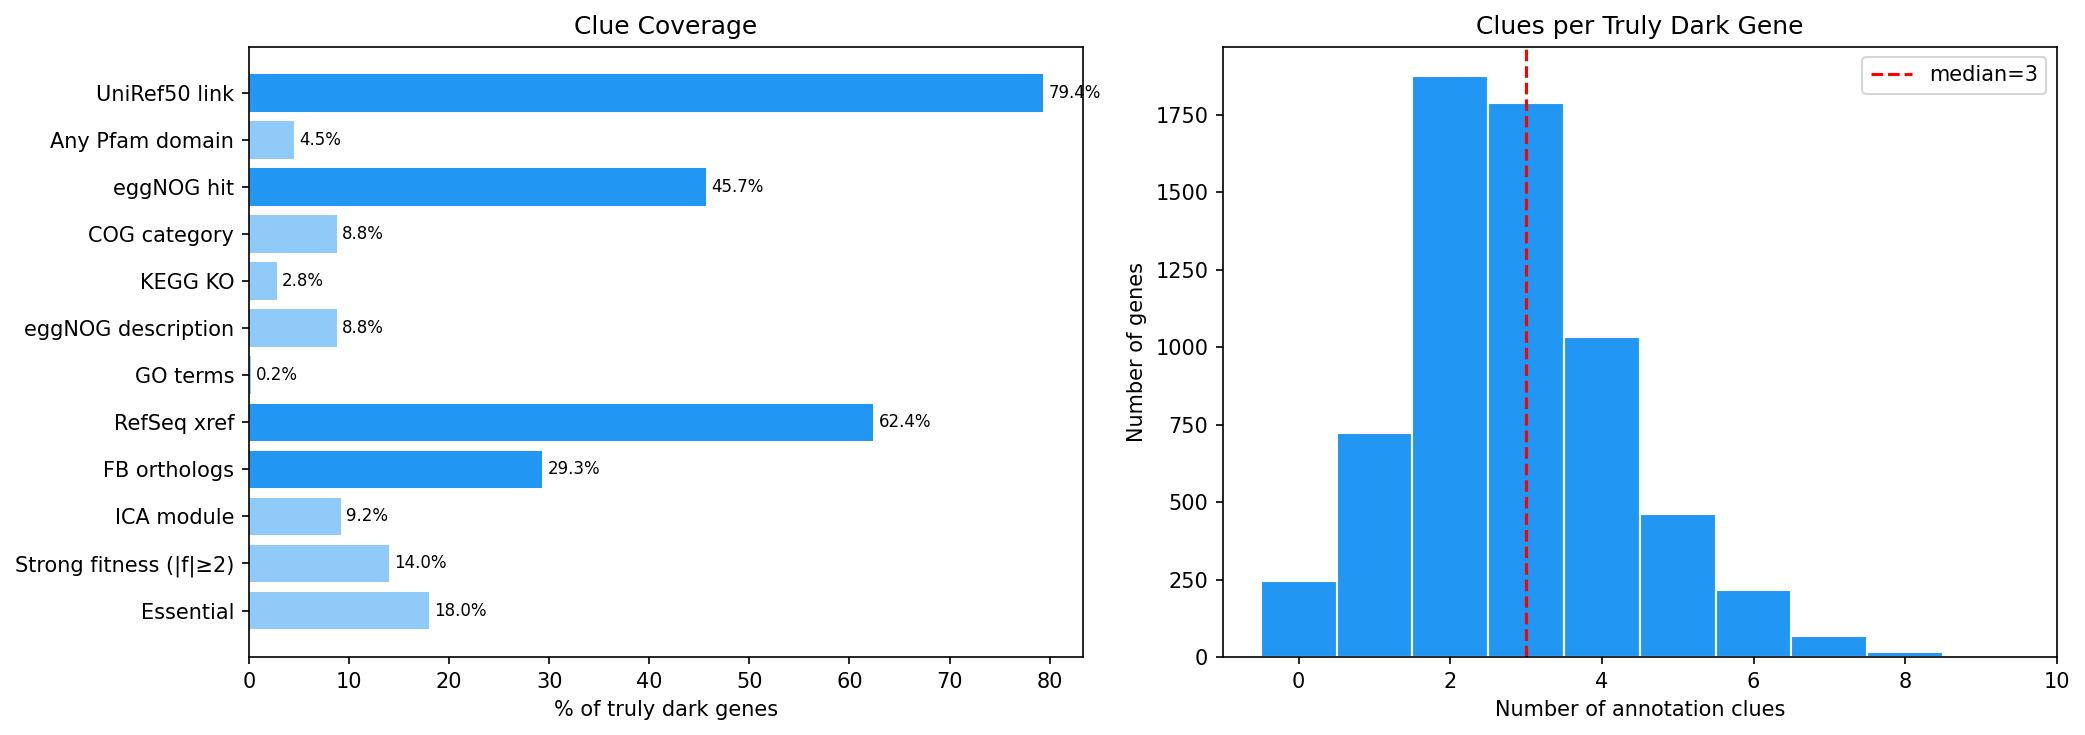

Saved: fig04_clue_coverage.png


In [6]:
# Visualize clue coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of clue coverage
ax = axes[0]
labels = [l for _, l in clue_cols]
vals = [clue[c].sum() / len(clue) * 100 for c, _ in clue_cols]
colors = ['#2196F3' if v > 20 else '#90CAF9' for v in vals]
bars = ax.barh(range(len(labels)), vals, color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('% of truly dark genes')
ax.set_title('Clue Coverage')
ax.invert_yaxis()
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=8)

# Right: histogram of clues per gene
ax = axes[1]
ax.hist(clue['n_clues'], bins=range(0, clue['n_clues'].max() + 2), 
        color='#2196F3', edgecolor='white', align='left')
ax.set_xlabel('Number of annotation clues')
ax.set_ylabel('Number of genes')
ax.set_title('Clues per Truly Dark Gene')
ax.axvline(clue['n_clues'].median(), color='red', ls='--', label=f'median={clue["n_clues"].median():.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG}/fig04_clue_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig04_clue_coverage.png')

## 4. Clue Profile Clustering

Group truly dark genes by their combination of available clues to identify distinct subtypes.

In [7]:
# Create a clue profile string for each gene
clue['profile'] = clue[binary_cols].astype(int).apply(
    lambda row: ''.join(row.astype(str)), axis=1
)

# Summarize profiles
profile_counts = clue['profile'].value_counts()
print(f'Unique clue profiles: {len(profile_counts)}')
print(f'\nTop 15 profiles (binary: {" | ".join([l[:8] for _, l in clue_cols])}):')
for prof, cnt in profile_counts.head(15).items():
    clue_names = [l for (c, l), bit in zip(clue_cols, prof) if bit == '1']
    label = ', '.join(clue_names) if clue_names else 'NO CLUES'
    print(f'  {prof} ({cnt:>5,} genes): {label}')

# Define interpretable tiers
def classify_tier(row):
    if row['n_clues'] == 0:
        return 'Tier 1: No clues'
    elif row['n_clues'] <= 2 and not row['has_pfam'] and not row['has_eggnog_desc']:
        return 'Tier 2: Minimal (sequence ID only)'
    elif row['has_pfam'] or row['has_eggnog_desc'] or row['has_cog']:
        return 'Tier 3: Partial function'
    elif row['in_module'] or row['has_strong_fitness'] or row['is_essential']:
        return 'Tier 4: Phenotype only'
    else:
        return 'Tier 2: Minimal (sequence ID only)'

clue['tier'] = clue.apply(classify_tier, axis=1)
print(f'\nAnnotation tiers:')
print(clue['tier'].value_counts().sort_index().to_string())

Unique clue profiles: 186

Top 15 profiles (binary: UniRef50 | Any Pfam | eggNOG h | COG cate | KEGG KO | eggNOG d | GO terms | RefSeq x | FB ortho | ICA modu | Strong f | Essentia):
  100000010000 (1,158 genes): UniRef50 link, RefSeq xref
  101000010000 (  640 genes): UniRef50 link, eggNOG hit, RefSeq xref
  101000011000 (  441 genes): UniRef50 link, eggNOG hit, RefSeq xref, FB orthologs
  100000000000 (  371 genes): UniRef50 link
  100000010001 (  369 genes): UniRef50 link, RefSeq xref, Essential
  000000000000 (  246 genes): NO CLUES
  100000010010 (  186 genes): UniRef50 link, RefSeq xref, Strong fitness (|f|≥2)
  100000011000 (  180 genes): UniRef50 link, RefSeq xref, FB orthologs
  001000001000 (  161 genes): eggNOG hit, FB orthologs
  101000010001 (  150 genes): UniRef50 link, eggNOG hit, RefSeq xref, Essential
  101000000000 (  139 genes): UniRef50 link, eggNOG hit
  100000000001 (  125 genes): UniRef50 link, Essential
  000000000001 (  120 genes): Essential
  101000011001 (  1

## 5. Pfam Domain Analysis for Truly Dark Genes

In [8]:
# Pfam class distribution
print('Pfam sub-stratification:')
print(clue['pfam_class'].value_counts().to_string())

# Non-DUF Pfam domains — these are the most informative
nonduf = pfam[~pfam['is_duf']].copy()
print(f'\nNon-DUF Pfam domains ({len(nonduf)} hits):')
print(nonduf['pfam_name'].value_counts().head(20).to_string())

# DUF domains
duf = pfam[pfam['is_duf']].copy()
print(f'\nDUF/UPF domains ({len(duf)} hits):')
print(duf['pfam_name'].value_counts().head(15).to_string())

Pfam sub-stratification:
pfam_class
none        6139
non_duf      220
duf_only      68

Non-DUF Pfam domains (294 hits):
pfam_name
TPR_19                 9
TPR_17                 7
TPR_14                 6
TPR_2                  6
TPR_8                  6
TPR_16                 5
TPR_12                 4
TPR_6                  4
Xre-like-HTH           3
Xre_MbcA_ParS_C        3
RHS_repeat             3
TPR_1                  3
TPR_10                 3
TPR_11                 3
S_layer_C              3
DsrE                   2
Mtrc-MtrF_II-IV_dom    2
Paired_CXXCH_1         2
ANAPC3                 2
TPR_9                  2

DUF/UPF domains (68 hits):
pfam_name
DUF7716    3
DUF7661    3
DUF7673    3
DUF6630    3
DUF553     3
DUF7740    2
DUF7693    2
DUF1302    2
DUF364     2
DUF4442    1
DUF1127    1
DUF4131    1
DUF6901    1
DUF2887    1
DUF7734    1


## 6. eggNOG COG Category Analysis

In [9]:
# COG category distribution for truly dark genes with COG assignments
has_cog = eggnog['cog_category'].notna() & (eggnog['cog_category'] != '-') & (eggnog['cog_category'] != '')
cog_genes = eggnog[has_cog].copy()
print(f'Genes with COG: {len(cog_genes)}')

# Expand multi-letter COG categories
cog_letters = []
for _, row in cog_genes.iterrows():
    for c in str(row['cog_category']):
        if c.isalpha():
            cog_letters.append({'gene_cluster_id': row['gene_cluster_id'], 'cog': c})
cog_expanded = pd.DataFrame(cog_letters)

# COG category names
cog_names = {
    'S': 'Function unknown', 'R': 'General function prediction',
    'L': 'Replication/repair', 'K': 'Transcription',
    'T': 'Signal transduction', 'M': 'Cell wall/membrane',
    'C': 'Energy production', 'E': 'Amino acid transport',
    'J': 'Translation/ribosome', 'O': 'Posttransl. modification',
    'U': 'Intracellular trafficking', 'N': 'Cell motility',
    'P': 'Inorganic ion transport', 'G': 'Carbohydrate transport',
    'F': 'Nucleotide transport', 'H': 'Coenzyme transport',
    'V': 'Defense mechanisms', 'I': 'Lipid transport',
    'D': 'Cell cycle control', 'Q': 'Secondary metabolites',
}

cog_dist = cog_expanded['cog'].value_counts()
print(f'\nCOG category distribution (excluding S={cog_dist.get("S", 0)}):')
for cog, cnt in cog_dist.items():
    if cog != 'S':
        name = cog_names.get(cog, '?')
        print(f'  {cog} ({name:<30}): {cnt:>4}')

# What fraction are just "S" (unknown)?
s_only = cog_genes[cog_genes['cog_category'].str.strip() == 'S']
print(f'\nCOG "S" only (function unknown): {len(s_only)} / {len(cog_genes)} ({len(s_only)/len(cog_genes)*100:.1f}%)')
print(f'COG non-S (some functional signal): {len(cog_genes) - len(s_only)}')

Genes with COG: 433

COG category distribution (excluding S=240):
  L (Replication/repair            ):   34
  M (Cell wall/membrane            ):   22
  K (Transcription                 ):   18
  T (Signal transduction           ):   16
  C (Energy production             ):   16
  J (Translation/ribosome          ):   16
  O (Posttransl. modification      ):   15
  U (Intracellular trafficking     ):   14
  N (Cell motility                 ):   13
  P (Inorganic ion transport       ):   13
  E (Amino acid transport          ):   11
  G (Carbohydrate transport        ):    9
  F (Nucleotide transport          ):    7
  H (Coenzyme transport            ):    6
  Q (Secondary metabolites         ):    6
  I (Lipid transport               ):    3
  D (Cell cycle control            ):    3
  V (Defense mechanisms            ):    2

COG "S" only (function unknown): 240 / 433 (55.4%)
COG non-S (some functional signal): 193


## 7. Module Context — What Do Co-regulated Annotated Genes Tell Us?

In [10]:
# For truly dark genes in modules, load the module annotations to see
# what annotated genes share the module (guilt by association)
td_in_modules = clue[clue['in_module']].copy()
print(f'Truly dark genes in ICA modules: {len(td_in_modules)}')

if len(td_in_modules) > 0:
    # Load module annotations for relevant organisms
    module_annot_list = []
    for org in td_in_modules['orgId'].unique():
        annot_file = f'{FM_DIR}/{org}_module_annotations.csv'
        if os.path.exists(annot_file):
            ma = pd.read_csv(annot_file)
            ma['orgId'] = org
            module_annot_list.append(ma)
    
    if module_annot_list:
        module_annots = pd.concat(module_annot_list, ignore_index=True)
        # Filter to modules containing truly dark genes
        td_module_pairs = []
        for _, row in td_in_modules.iterrows():
            for mid in str(row.get('module_ids', '')).split(','):
                if mid:
                    td_module_pairs.append({'orgId': row['orgId'], 'module': mid})
        td_modules_df = pd.DataFrame(td_module_pairs).drop_duplicates()
        
        # Get significant annotations for these modules
        sig_annots = module_annots[module_annots['significant'] == True].copy()
        relevant = sig_annots.merge(td_modules_df, on=['orgId', 'module'])
        
        print(f'\nModules containing TD genes: {len(td_modules_df)}')
        print(f'Significant annotations in these modules: {len(relevant)}')
        if len(relevant) > 0:
            print(f'\nTop module annotations (guilt-by-association):')
            top = relevant.groupby(['orgId', 'module', 'term', 'database']).agg(
                odds_ratio=('odds_ratio', 'first'),
                fdr=('fdr', 'first')
            ).reset_index().sort_values('odds_ratio', ascending=False)
            for _, row in top.head(20).iterrows():
                print(f'  {row["orgId"]} {row["module"]}: {row["term"]} ({row["database"]}, OR={row["odds_ratio"]:.1f})')
    else:
        print('No module annotation files found')
else:
    print('No truly dark genes found in ICA modules')

Truly dark genes in ICA modules: 594

Modules containing TD genes: 318
Significant annotations in these modules: 1478

Top module annotations (guilt-by-association):
  pseudo3_N2E3 M021: TIGR00842 (TIGRFam, OR=inf)
  ANA3 M007: Site-specific recombinase, phage integrase family (SEED, OR=inf)
  pseudo5_N2C3_1 M007: Lead, cadmium, zinc and mercury transporting ATPase (EC 3.6.3.3) (EC 3.6.3.5); Copper-translocating P-type ATPase (EC 3.6.3.4) (SEED, OR=inf)
  acidovorax_3H11 M015: PF13641 (PFam, OR=inf)
  acidovorax_3H11 M015: Signal transduction histidine kinase CheA (EC 2.7.3.-) (SEED, OR=inf)
  acidovorax_3H11 M015: PF03170 (PFam, OR=inf)
  acidovorax_3H11 M015: PF03552 (PFam, OR=inf)
  acidovorax_3H11 M015: PF05420 (PFam, OR=inf)
  acidovorax_3H11 M015: TIGR03030 (TIGRFam, OR=inf)
  psRCH2 M017: Iron-regulated protein A precursor (SEED, OR=inf)
  psRCH2 M017: PF09375 (PFam, OR=inf)
  Korea M020: PF17289 (PFam, OR=inf)
  Korea M020: PF03237 (PFam, OR=inf)
  DvH M026: PF00696 (PFam, OR=i

## 8. Clue-Concordance Validation

Test whether genes with more clues have higher cross-organism concordance.

In [11]:
# Load concordance data from parent project
conc_file = f'{FDM_DIR}/concordance_scores.tsv'
if os.path.exists(conc_file):
    conc = pd.read_csv(conc_file, sep='\t')
    print(f'Concordance data: {len(conc):,} gene pairs')
    print(f'Columns: {list(conc.columns)}')
    
    # Match truly dark genes to concordance data
    # concordance_scores has orgId, locusId columns
    td_keys = set(zip(clue['orgId'], clue['locusId']))
    
    # Check which column names are used
    if 'orgId' in conc.columns and 'locusId' in conc.columns:
        conc_td = conc[conc.apply(lambda r: (r['orgId'], str(r['locusId'])) in td_keys, axis=1)]
        print(f'Concordance entries for truly dark genes: {len(conc_td):,}')
    else:
        print(f'Concordance columns: {list(conc.columns)}')
        conc_td = pd.DataFrame()
    
    if len(conc_td) > 0:
        # Merge clue count with concordance
        conc_td = conc_td.copy()
        conc_td['locusId'] = conc_td['locusId'].astype(str)
        conc_clue = conc_td.merge(
            clue[['orgId', 'locusId', 'n_clues', 'tier']],
            on=['orgId', 'locusId'], how='left'
        )
        
        # Check for a concordance score column
        score_col = None
        for candidate in ['concordance_score', 'concordance', 'score', 'n_concordant', 'frac_concordant']:
            if candidate in conc_clue.columns:
                score_col = candidate
                break
        
        if score_col:
            from scipy import stats
            corr, pval = stats.spearmanr(
                conc_clue['n_clues'].dropna(), 
                conc_clue[score_col].dropna()
            )
            print(f'\nClue count vs concordance ({score_col}):')
            print(f'  Spearman r={corr:.3f}, p={pval:.2e}')
            print(f'\nMean concordance by clue count:')
            print(conc_clue.groupby('n_clues')[score_col].agg(['mean', 'count']).to_string())
        else:
            print(f'No concordance score column found. Available: {list(conc_clue.columns)}')
else:
    print(f'Concordance file not found: {conc_file}')
    print('Skipping clue-concordance validation (will address in NB04)')

Concordance data: 65 gene pairs
Columns: ['ogId', 'best_condition', 'max_concordance', 'max_strong_concordance', 'n_condition_classes', 'n_concordant_conditions', 'total_organisms']
Concordance columns: ['ogId', 'best_condition', 'max_concordance', 'max_strong_concordance', 'n_condition_classes', 'n_concordant_conditions', 'total_organisms']


## 9. Tier Summary and Visualization

/tmp/ipykernel_61015/1937036075.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_tier, labels=[t.split(': ')[1] for t in tier_order],


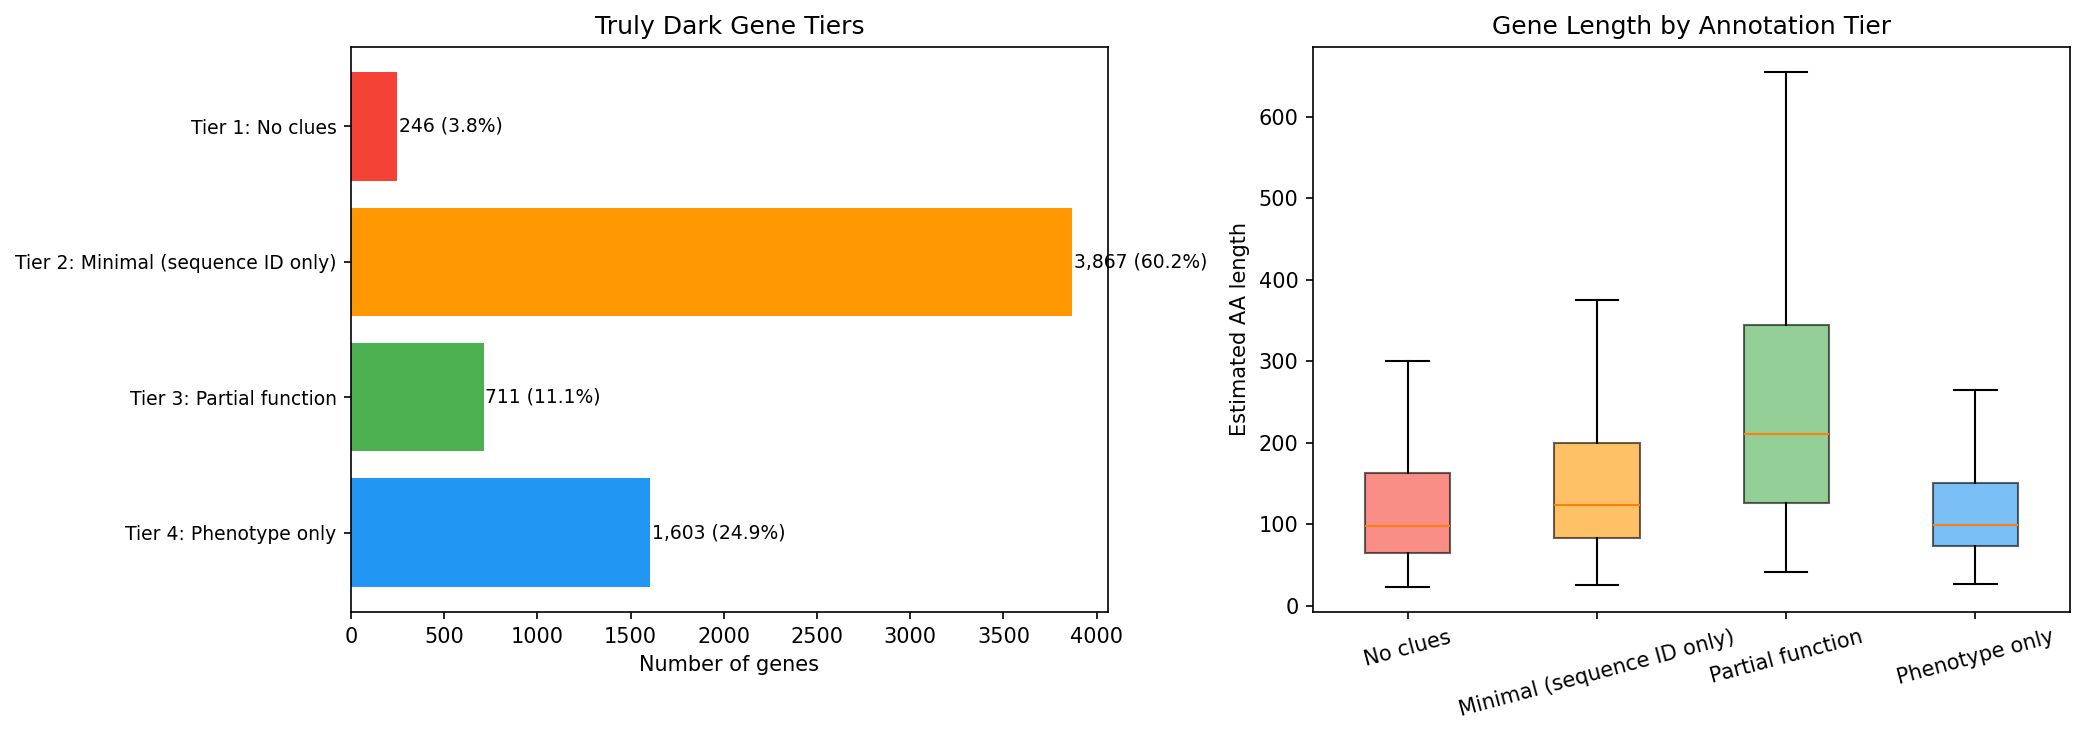

Saved: fig05_annotation_tiers.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: tier distribution
ax = axes[0]
tier_counts = clue['tier'].value_counts().sort_index()
colors_tier = ['#f44336', '#ff9800', '#4caf50', '#2196f3']
bars = ax.barh(range(len(tier_counts)), tier_counts.values, color=colors_tier[:len(tier_counts)])
ax.set_yticks(range(len(tier_counts)))
ax.set_yticklabels(tier_counts.index, fontsize=9)
ax.set_xlabel('Number of genes')
ax.set_title('Truly Dark Gene Tiers')
ax.invert_yaxis()
for bar, v in zip(bars, tier_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({v/len(clue)*100:.1f}%)', va='center', fontsize=9)

# Right: gene length by tier
ax = axes[1]
tier_order = sorted(clue['tier'].unique())
data_by_tier = [clue.loc[clue['tier'] == t, 'est_aa_length'].dropna() for t in tier_order]
bp = ax.boxplot(data_by_tier, labels=[t.split(': ')[1] for t in tier_order], 
                showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_tier):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Estimated AA length')
ax.set_title('Gene Length by Annotation Tier')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{FIG}/fig05_annotation_tiers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig05_annotation_tiers.png')

## 10. Save and Summary

In [13]:
# Save the full clue matrix
clue.to_csv(f'{OUT}/truly_dark_clue_matrix.tsv', sep='\t', index=False)
print(f'Saved: truly_dark_clue_matrix.tsv ({os.path.getsize(f"{OUT}/truly_dark_clue_matrix.tsv")/1024:.0f} KB)')

print(f'\n=== NB03 Complete ===')
print(f'\nClue matrix: {len(clue):,} genes x {len(clue.columns)} columns')
print(f'\nTier distribution:')
for tier, cnt in clue['tier'].value_counts().sort_index().items():
    print(f'  {tier}: {cnt:,} ({cnt/len(clue)*100:.1f}%)')
print(f'\nKey findings:')
print(f'  Genes with zero clues: {(clue["n_clues"] == 0).sum():,}')
print(f'  Genes with partial function (Pfam/COG/eggNOG): {clue["tier"].str.contains("Partial").sum():,}')
print(f'  Genes in ICA modules: {clue["in_module"].sum():,}')
print(f'  Mean clues per gene: {clue["n_clues"].mean():.1f}')

Saved: truly_dark_clue_matrix.tsv (1529 KB)

=== NB03 Complete ===

Clue matrix: 6,427 genes x 41 columns

Tier distribution:
  Tier 1: No clues: 246 (3.8%)
  Tier 2: Minimal (sequence ID only): 3,867 (60.2%)
  Tier 3: Partial function: 711 (11.1%)
  Tier 4: Phenotype only: 1,603 (24.9%)

Key findings:
  Genes with zero clues: 246
  Genes with partial function (Pfam/COG/eggNOG): 711
  Genes in ICA modules: 594
  Mean clues per gene: 2.8
